Recalled a previous cleaned file from ModB to bring back all Data cleanining efforts. 

In [5]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
# Recall Brazil Cancer dataset in a way that i may commit changes to github

import os
import zipfile
import pandas as pd
import tempfile

# create temporary directory (not inside repo)
temp_dir = tempfile.gettempdir()
data_dir = os.path.join(temp_dir, "brazil_cancer_data")

os.makedirs(data_dir, exist_ok=True)

zip_path = os.path.join(data_dir, "cancer-data-brazil.zip")
csv_path = os.path.join(data_dir, "cancer_data_eng.csv")

# download if not already present
if not os.path.exists(csv_path):

    os.system(f"kaggle datasets download joaopedromedeiros/cancer-data-brazil -p {data_dir}")

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(data_dir)

df = pd.read_csv(csv_path, encoding="ISO-8859-1")

print(df.head())

Dataset URL: https://www.kaggle.com/datasets/joaopedromedeiros/cancer-data-brazil
License(s): CC0-1.0


100%|██████████| 60.1M/60.1M [00:01<00:00, 44.1MB/s]


/tmp/ipykernel_7666/3394368465.py:25: DtypeWarning: Columns (0: Date.of.Birth, 1: Raca.Color, 2: Nationality, 3: Naturality.State, 4: Naturality, 5: Degree.of.Education, 6: State.Civil, 7: Status.Address, 8: City.Address, 9: Youth.Adult.Illness.Description, 10: Code.of.Disease.Adult.Young., 11: Indicator.of.Rare.Case, 12: Extension, 13: Laterality, 14: Statement, 15: TNM, 16: Status.Vital, 17: Type.of.Death, 18: Date.of.Death, 19: Date.of.Last.Contact, 20: Date.of.Diagnostic, 21: Distant.metastasis) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path, encoding="ISO-8859-1")


   Patient.Code              RCBP.Name     Gender Date.of.Birth   Age  \
0      672054.0  RCBP CAMPINAS-UNICAMP  MASCULINO    1975-03-16  30.0   
1      673213.0  RCBP CAMPINAS-UNICAMP   FEMININO    1950-05-24  53.0   
2      673396.0  RCBP CAMPINAS-UNICAMP   FEMININO    1951-09-02  51.0   
3      673425.0  RCBP CAMPINAS-UNICAMP   FEMININO    1929-11-21  73.0   
4      673745.0  RCBP CAMPINAS-UNICAMP  MASCULINO    1934-07-03  71.0   

  Raca.Color Nationality Naturality.State Naturality Degree.of.Education  ...  \
0     BRANCO      BRASIL        SÃO PAULO        NaN                 NaN  ...   
1        NaN         NaN              NaN        NaN                 NaN  ...   
2      PARDA      BRASIL        SÃO PAULO        NaN                 NaN  ...   
3        NaN         NaN              NaN        NaN                 NaN  ...   
4     BRANCO      BRASIL        SÃO PAULO        NaN                 NaN  ...   

  Laterality  Statement  TNM Status.Vital Type.of.Death Date.of.Death  \
0

In [14]:
#Recall data cleaning efforts from week 4.  

df["Date.of.Birth"] = pd.to_datetime(df["Date.of.Birth"], errors="coerce")
df["Date.of.Diagnostic"] = pd.to_datetime(df["Date.of.Diagnostic"], errors="coerce")

df.loc[df["Age"] >= 116, "Age"] = None
df.loc[df["Age"] <= 0, "Age"] = None


df.loc[
    df["Date.of.Birth"].isna() & df["Age"].notna(),
    "Date.of.Birth"
] = df["Date.of.Diagnostic"] - pd.to_timedelta(df["Age"] * 365.25, unit="D")

df[["Age", "Date.of.Birth"]].isnull().sum()

columns_encode = [
    "Gender",
    "Raca.Color",
    "Nationality",
    "Degree.of.Education",
    "State.Civil",
    "Status.Address",
    "Indicator.of.Rare.Case",
    "Diagnostic.means",
    "Extension",
    "Laterality",
    "Statement",
    "Status.Vital",
    "Type.of.Death",
]

df_encoded = pd.get_dummies(df, columns=columns_encode, drop_first=True)

In [15]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns

numeric_cols, categorical_cols

/tmp/ipykernel_7666/283104828.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns


(Index(['Patient.Code', 'Age', 'Code.Profession', 'Code.of.Morphology', 'year'], dtype='str'),
 Index(['RCBP.Name', 'Gender', 'Raca.Color', 'Nationality', 'Naturality.State',
        'Naturality', 'Degree.of.Education', 'State.Civil', 'Name.Occupation',
        'Status.Address', 'City.Address', 'Description.of.Topography',
        'Topography.Code', 'Morphology.Description', 'Description.of.Disease',
        'Illness.Code', 'Child.Illness.Description', 'Child.Illness.Code',
        'Youth.Adult.Illness.Description', 'Code.of.Disease.Adult.Young.',
        'Indicator.of.Rare.Case', 'Diagnostic.means', 'Extension', 'Laterality',
        'Statement', 'TNM', 'Status.Vital', 'Type.of.Death', 'Date.of.Death',
        'Date.of.Last.Contact', 'Distant.metastasis'],
       dtype='str'))

In [19]:
df_encoded.head()

,Patient.Code,RCBP.Name,Date.of.Birth,Age,Naturality.State,Naturality,Code.Profession,Name.Occupation,City.Address,Description.of.Topography,...,Statement_TIS,Statement_VA,Statement_VI,Statement_VIIIA,Statement_X,Statement_XX,Statement_XXX,Statement_Y,Status.Vital_VIVO,Type.of.Death_NÃO CÂNCER
0,672054.0,RCBP CAMPINAS-UNICAMP,1975-03-16,30.0,SÃO PAULO,NaN,516.0,TRABALHADORES NOS SERVIÇOS DE EMBELEZAMENTO E ...,CAMPINAS,"RETO, SOE",...,False,False,False,False,False,False,False,False,False,False
1,673213.0,RCBP CAMPINAS-UNICAMP,1950-05-24,53.0,NaN,NaN,0.0,SEM INFORMAÇÃO\t,CAMPINAS,COLON DESCENDENTE,...,False,False,False,False,False,False,False,False,False,False
2,673396.0,RCBP CAMPINAS-UNICAMP,1951-09-02,51.0,SÃO PAULO,NaN,0.0,SEM INFORMAÇÃO\t,CAMPINAS,"MAMA , SOE",...,False,False,False,False,False,False,False,False,False,False
3,673425.0,RCBP CAMPINAS-UNICAMP,1929-11-21,73.0,NaN,NaN,0.0,SEM INFORMAÇÃO\t,CAMPINAS,PELE DO MEMBRO SUPERIOR E DO OMBRO,...,False,False,False,False,False,False,False,False,True,False
4,673745.0,RCBP CAMPINAS-UNICAMP,1934-07-03,71.0,SÃO PAULO,NaN,0.0,SEM INFORMAÇÃO\t,CAMPINAS,"LOCALIZACAO PRIMARIA DESCONHECIDA, SOE",...,False,False,False,False,False,False,False,False,False,False


In [16]:
df_sample = df.sample(10000, random_state=42)

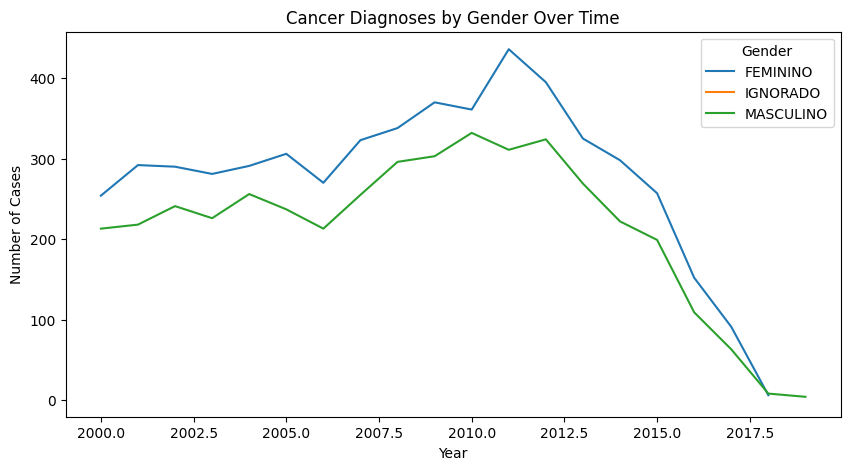

In [17]:
gender_year = df_sample.groupby(["year","Gender"]).size().unstack()

gender_year.plot(figsize=(10,5))
plt.title("Cancer Diagnoses by Gender Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Cases")
plt.show()

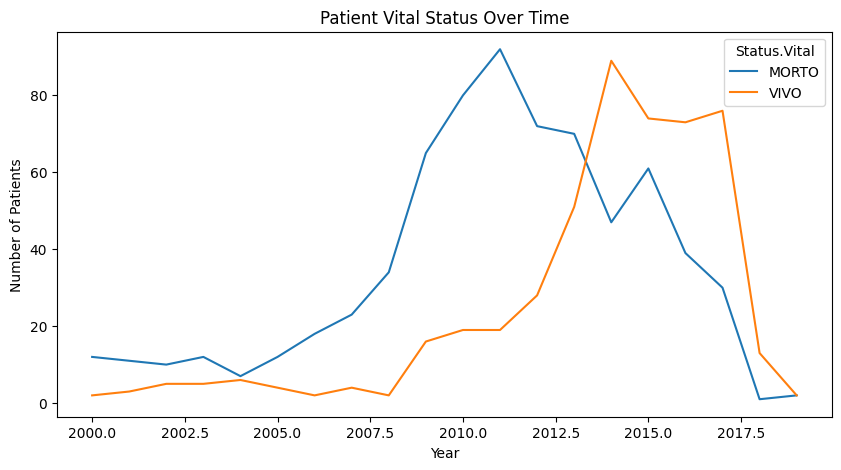

In [18]:
vital_year = df_sample.groupby(["year","Status.Vital"]).size().unstack()

vital_year.plot(figsize=(10,5))
plt.title("Patient Vital Status Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Patients")
plt.show()

In [20]:
df.select_dtypes(include=['number']).columns.tolist()

['Patient.Code', 'Age', 'Code.Profession', 'Code.of.Morphology', 'year']

Does profession, diagnosis year, cancer type explain differences in age at cancer diagnosis?

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


X = df[['Code.Profession', 'Code.of.Morphology', 'year']]
y = df['Age']

data = pd.concat([X, y], axis=1).dropna()

X = data[['Code.Profession', 'Code.of.Morphology', 'year']]
y = data['Age']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print(model.score(X_test, y_test))

0.049130931984456505


Given that this is a largely categorical dataset, i will be looking at others that have more reliance on numerical data, as this linear model does not tell much about the variability of the age at diagnosis in Brazil. 